In [18]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt
import datetime
%matplotlib inline

1. Загрузка данных и разбивка на train/test

In [19]:
data = pd.read_csv('gbm-data.csv')
X = data.iloc[:, 1:].values
y = data.iloc[:, 0].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.8, random_state=241
)

2. Обучите GradientBoostingClassifier с параметрами n_estimators=250,
verbose=True, random_state=241 и для каждого значения learning_rate
из списка [1, 0.5, 0.3, 0.2, 0.1] 

In [20]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

learning_rates = [1, 0.5, 0.3, 0.2, 0.1]
results = {}

for lr in learning_rates:
    clf = GradientBoostingClassifier(
        n_estimators=250, learning_rate=lr, random_state=241, verbose=False
    )
    clf.fit(X_train, y_train)

    train_loss, test_loss = [], []
    for pred_train, pred_test in zip(
        clf.staged_decision_function(X_train),
        clf.staged_decision_function(X_test)
    ):
        train_loss.append(log_loss(y_train, sigmoid(pred_train)))
        test_loss.append(log_loss(y_test, sigmoid(pred_test)))

    results[lr] = {
        'train_loss': train_loss,
        'test_loss': test_loss,
        'best_iter': np.argmin(test_loss) + 1,
        'best_loss': min(test_loss),
    }

3. Как можно охарактеризовать график качества на тестовой выборке, начиная с некоторой итерации: переобучение (overfitting) или недообучение (underfitting)? В ответе укажите одно из слов overfitting либо underfitting.

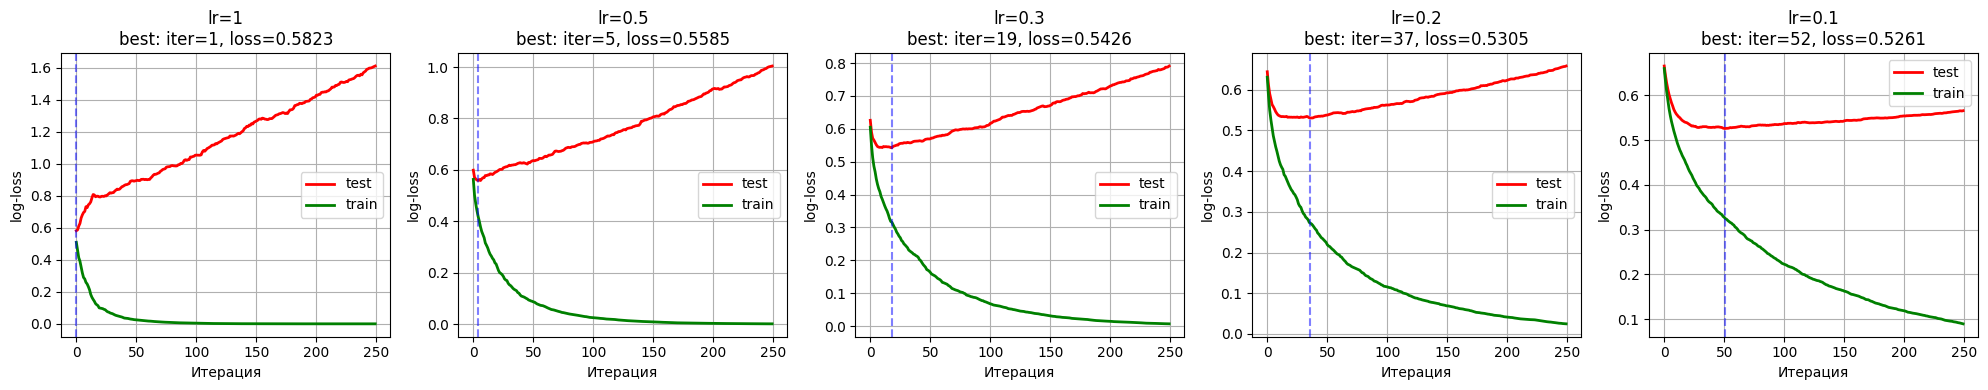

overfitting


In [21]:
fig, axes = plt.subplots(1, len(learning_rates), figsize=(20, 4))

for ax, lr in zip(axes, learning_rates):
    r = results[lr]
    ax.plot(r['test_loss'], 'r', linewidth=2, label='test')
    ax.plot(r['train_loss'], 'g', linewidth=2, label='train')
    ax.axvline(x=r['best_iter']-1, color='b', linestyle='--', alpha=0.5)
    ax.set_title(f'lr={lr}\nbest: iter={r["best_iter"]}, loss={r["best_loss"]:.4f}')
    ax.set_xlabel('Итерация')
    ax.set_ylabel('log-loss')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()
print('overfitting')

4. Приведите минимальное значение log-loss на тестовой выборке и номер итерации, на котором оно достигается, при learning_rate = 0.2.

In [22]:
lr_02 = results[0.2]
print(f'{lr_02["best_loss"]:.2f} {lr_02["best_iter"]}' )

0.53 37


5. На этих же данных обучите RandomForestClassifier с количеством деревьев, равным количеству итераций, на котором достигается наилучшее качество у градиентного бустинга из предыдущего пункта, random_state=241 и остальными параметрами по умолчанию.Какое значение log-loss на тесте получается у этого случайного леса?

In [23]:
rf = RandomForestClassifier(n_estimators=lr_02['best_iter'], random_state=241)
rf.fit(X_train, y_train)

rf_pred = rf.predict_proba(X_test)[:, 1]
print(round(log_loss(y_test, rf_pred), 2))

0.54
